In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

| Variable  | Description                                                           |
|-----------|-----------------------------------------------------------------------|
| ZN        | Proportion of residential land zoned for lots over 25,000 sq.ft.      |
| INDUS     | Proportion of non-retail business acres per town                      |
| CHAS      | Charles River dummy variable (= 1 if tract bounds river; 0 otherwise) |
| NOX       | Nitric oxides concentration (parts per 10 million)                    |
| RM        | Average number of rooms per dwelling                                  |
| AGE       | Proportion of owner-occupied units built prior to 1940                |
| DIS       | Weighted distances to ﬁve Boston employment centers                   |
| RAD       | Index of accessibility to radial highways                             |
| TAX       | Full-value property-tax rate per $10,000                              |
| PTRATIO   | Pupil-teacher ratio by town                                           |
| B         | 1000(Bk−0.63)² where Bk is the proportion of blacks by town           |
| LSTAT     | % lower status of the population                                      |
| MEDV      | Median value of owner-occupied homes in 1000s(dollar)                 |


In [8]:
column_names = ['CRIM', 'ZN', 'INDUS', 'CHAS', 'NOX', 'RM', 'AGE', 'DIS', 'RAD', 'TAX', 'PTRATIO', 'B', 'LSTAT', 'MEDV']

In [9]:
data = pd.read_csv("23-boston_house_prices.csv", header=None, delimiter=r"\s+", names=column_names)

In [12]:
data

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296.0,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242.0,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242.0,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222.0,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222.0,18.7,396.90,5.33,36.2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
501,0.06263,0.0,11.93,0,0.573,6.593,69.1,2.4786,1,273.0,21.0,391.99,9.67,22.4
502,0.04527,0.0,11.93,0,0.573,6.120,76.7,2.2875,1,273.0,21.0,396.90,9.08,20.6
503,0.06076,0.0,11.93,0,0.573,6.976,91.0,2.1675,1,273.0,21.0,396.90,5.64,23.9
504,0.10959,0.0,11.93,0,0.573,6.794,89.3,2.3889,1,273.0,21.0,393.45,6.48,22.0


In [11]:
data.shape

(506, 14)

In [13]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 14 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   CRIM     506 non-null    float64
 1   ZN       506 non-null    float64
 2   INDUS    506 non-null    float64
 3   CHAS     506 non-null    int64  
 4   NOX      506 non-null    float64
 5   RM       506 non-null    float64
 6   AGE      506 non-null    float64
 7   DIS      506 non-null    float64
 8   RAD      506 non-null    int64  
 9   TAX      506 non-null    float64
 10  PTRATIO  506 non-null    float64
 11  B        506 non-null    float64
 12  LSTAT    506 non-null    float64
 13  MEDV     506 non-null    float64
dtypes: float64(12), int64(2)
memory usage: 55.5 KB


In [14]:
data.isnull().sum()

CRIM       0
ZN         0
INDUS      0
CHAS       0
NOX        0
RM         0
AGE        0
DIS        0
RAD        0
TAX        0
PTRATIO    0
B          0
LSTAT      0
MEDV       0
dtype: int64

In [15]:
data.describe()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
count,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000
mean,3.613524,11.363636,11.136779,0.069170,0.554695,6.284634,68.574901,3.795043,9.549407,408.237154,18.455534,356.674032,12.653063,22.532806
std,8.601545,23.322453,6.860353,0.253994,0.115878,0.702617,28.148861,2.105710,8.707259,168.537116,2.164946,91.294864,7.141062,9.197104
min,0.006320,0.000000,0.460000,0.000000,0.385000,3.561000,2.900000,1.129600,1.000000,187.000000,12.600000,0.320000,1.730000,5.000000
25%,0.082045,0.000000,5.190000,0.000000,0.449000,5.885500,45.025000,2.100175,4.000000,279.000000,17.400000,375.377500,6.950000,17.025000
50%,0.256510,0.000000,9.690000,0.000000,0.538000,6.208500,77.500000,3.207450,5.000000,330.000000,19.050000,391.440000,11.360000,21.200000
75%,3.677083,12.500000,18.100000,0.000000,0.624000,6.623500,94.075000,5.188425,24.000000,666.000000,20.200000,396.225000,16.955000,25.000000
max,88.976200,100.000000,27.740000,1.000000,0.871000,8.780000,100.000000,12.126500,24.000000,711.000000,22.000000,396.900000,37.970000,50.000000


In [38]:
import math

def all_hist(data, title_pre = ""):
    num_cols = data.select_dtypes(include=[np.number]).columns
    n_cols = 3
    n_rows = math.ceil(len(num_cols) / n_cols)

    plt.figure(figsize=(4*n_rows, 5*n_cols))

    for i, col in enumerate(num_cols, 1):
        plt.subplot(n_rows, n_cols, i)
        sns.histplot(data[col], kde=True, bins=30)
        plt.title(f"{title_pre} {col}")
        plt.xlabel("")

    plt.tight_layout()
    plt.show()

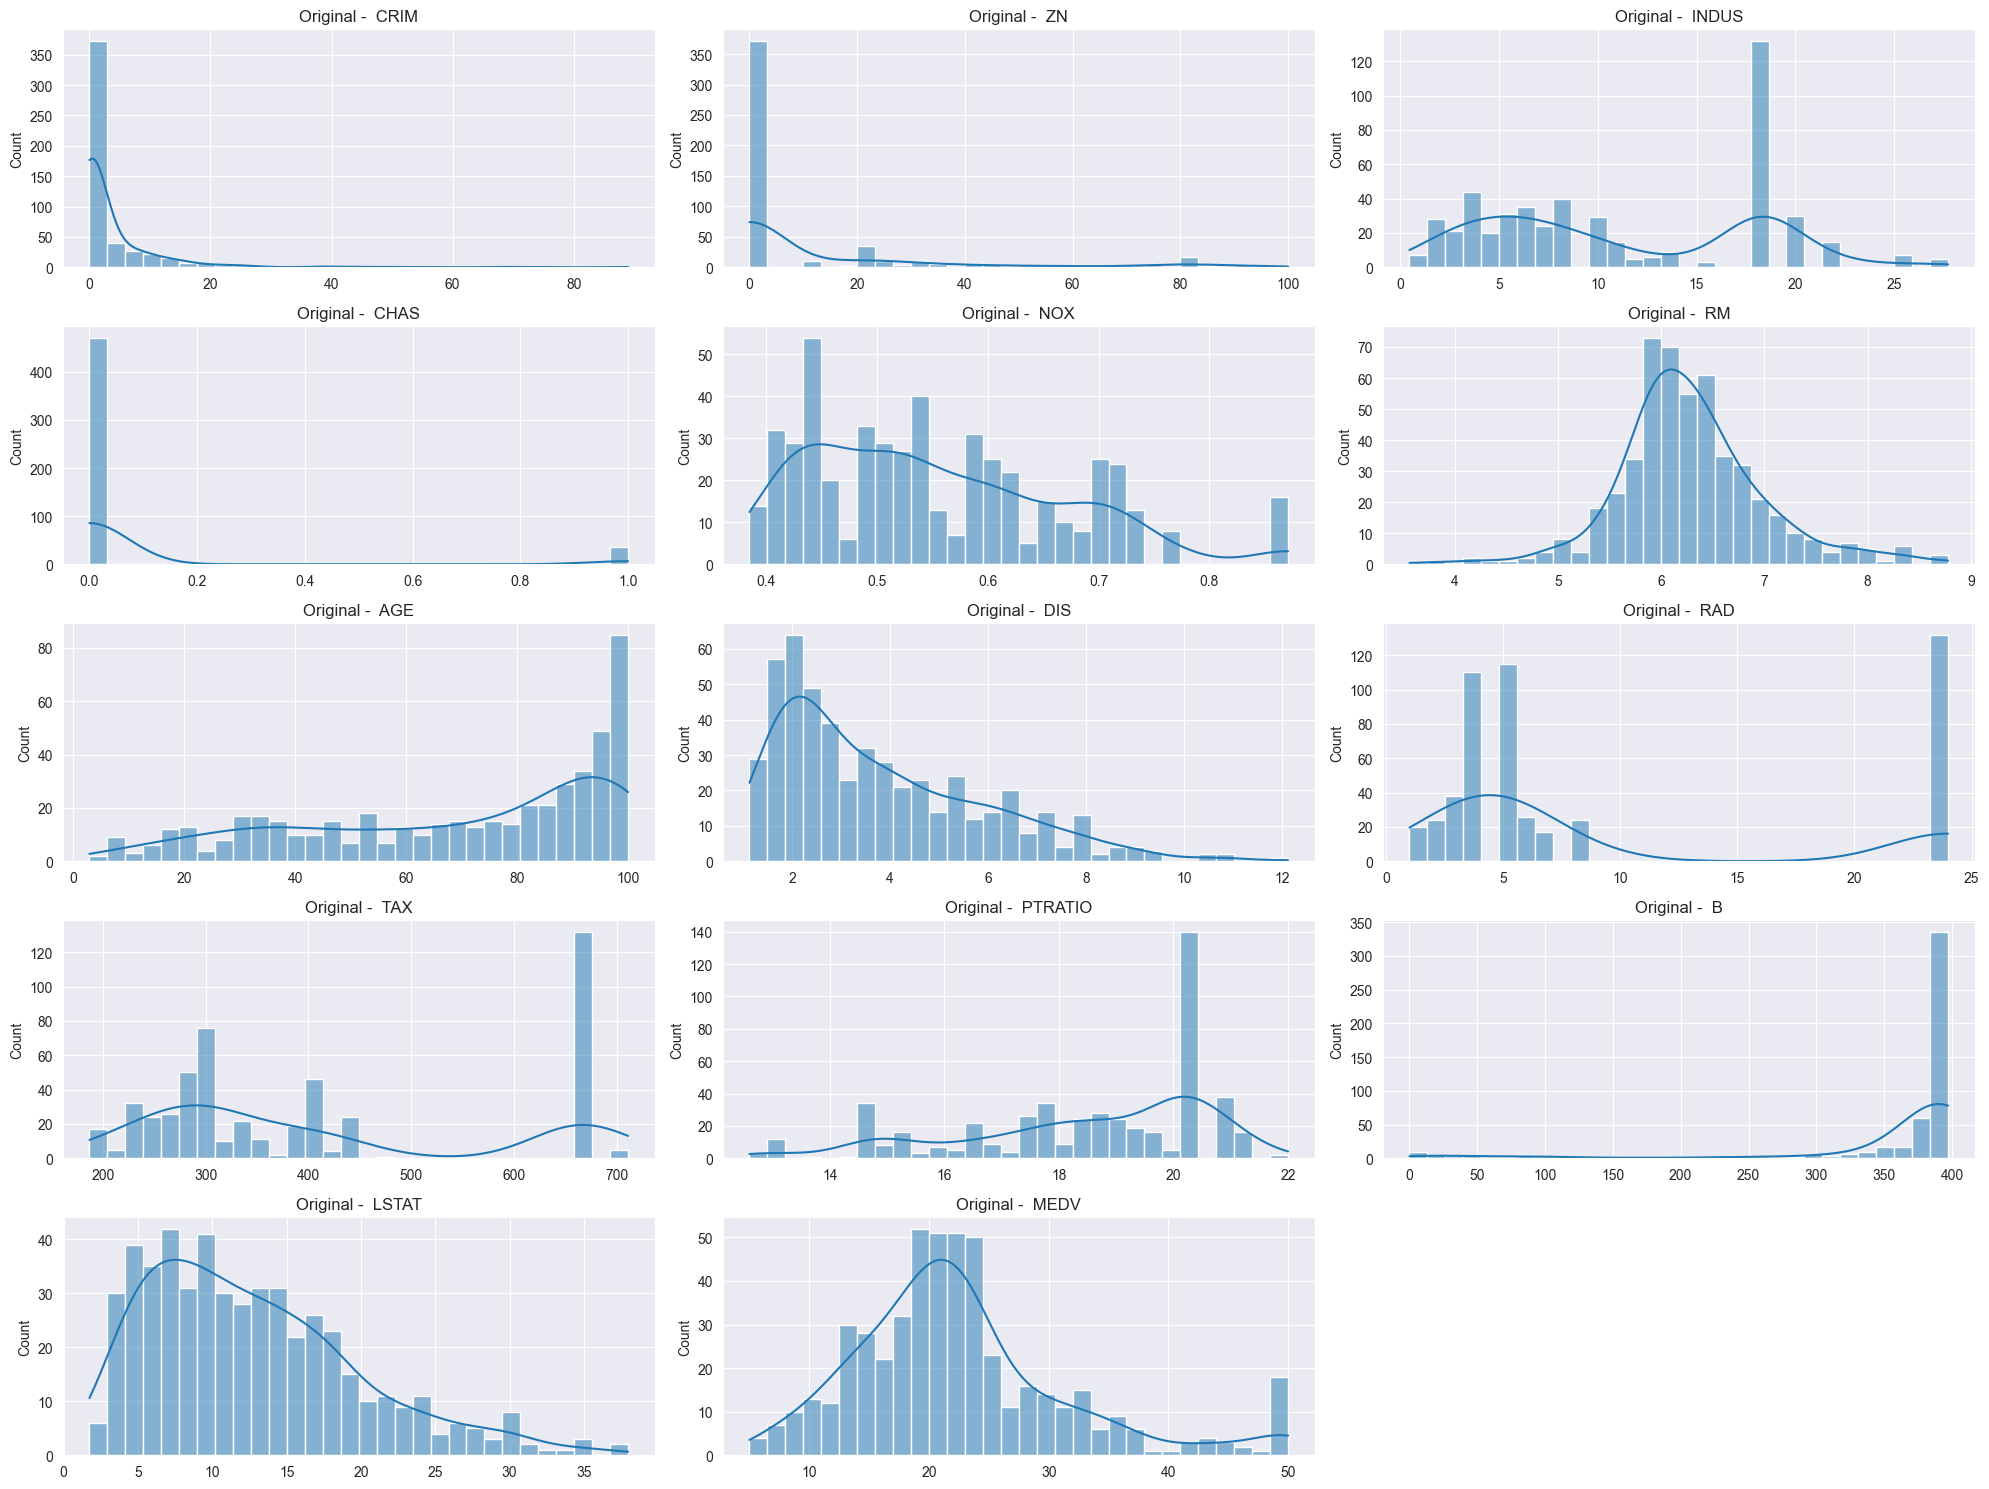

In [40]:
all_hist(data, title_pre="Original - ")

In [41]:
from scipy.stats import skew

In [43]:
data.apply(skew).sort_values(ascending=False)

CRIM       5.207652
CHAS       3.395799
ZN         2.219063
MEDV       1.104811
DIS        1.008779
RAD        1.001833
LSTAT      0.903771
NOX        0.727144
TAX        0.667968
RM         0.402415
INDUS      0.294146
AGE       -0.597186
PTRATIO   -0.799945
B         -2.881798
dtype: float64

In [44]:
X = data.drop("MEDV", axis=1)
y = data["MEDV"]

In [45]:
from sklearn.model_selection import train_test_split

In [46]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=15)

In [47]:
from sklearn.preprocessing import PowerTransformer

In [48]:
plt_X = PowerTransformer(method="yeo-johnson")

In [49]:
X_train_transformed = plt_X.fit_transform(X_train)
X_test_transformed = plt_X.transform(X_test)

In [50]:
column_names = ['CRIM', 'ZN', 'INDUS', 'CHAS', 'NOX', 'RM', 'AGE', 'DIS', 'RAD', 'TAX', 'PTRATIO', 'B', 'LSTAT']

X_train_transformed_df = pd.DataFrame(X_train_transformed, columns=column_names)

In [51]:
X_train_transformed_df

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT
0,-0.904167,1.724429,-1.219281,-0.267615,-1.133724,0.654830,-1.320696,1.297076,-0.255374,0.244488,-1.427362,0.426553,-1.322242
1,1.605896,-0.588616,1.011100,-0.267615,1.465402,-0.490305,0.689192,-1.115580,1.457243,1.370436,0.848622,-2.703630,2.139134
2,-0.925383,-0.588616,-1.492987,-0.267615,-0.496175,-0.175553,-0.053289,0.037511,-0.944274,-1.975622,-0.502857,0.350835,0.303698
3,0.999995,-0.588616,1.161199,-0.267615,2.026049,-0.985039,0.975581,-1.456339,-0.255374,0.275674,-1.555351,-0.550002,1.209644
4,-0.628294,-0.588616,0.138417,-0.267615,-1.475942,-0.043701,-1.910821,0.936406,-0.551621,-0.473029,0.216963,0.073562,-0.622936
...,...,...,...,...,...,...,...,...,...,...,...,...,...
399,1.668295,-0.588616,1.011100,-0.267615,1.072096,1.447764,1.100495,-1.734661,1.457243,1.370436,0.848622,0.643031,0.342306
400,-0.390949,-0.588616,1.382524,-0.267615,0.752694,-0.654775,0.996311,-0.517389,-0.551621,0.472960,1.592342,0.396688,0.542831
401,1.366441,-0.588616,1.011100,-0.267615,1.206460,0.184264,1.021234,-1.275079,1.457243,1.370436,0.848622,0.643031,1.013945
402,-0.636275,1.664783,-0.676234,-0.267615,-1.216540,-0.973231,-0.000938,1.644135,0.171014,-0.249768,0.159469,0.409545,0.922866


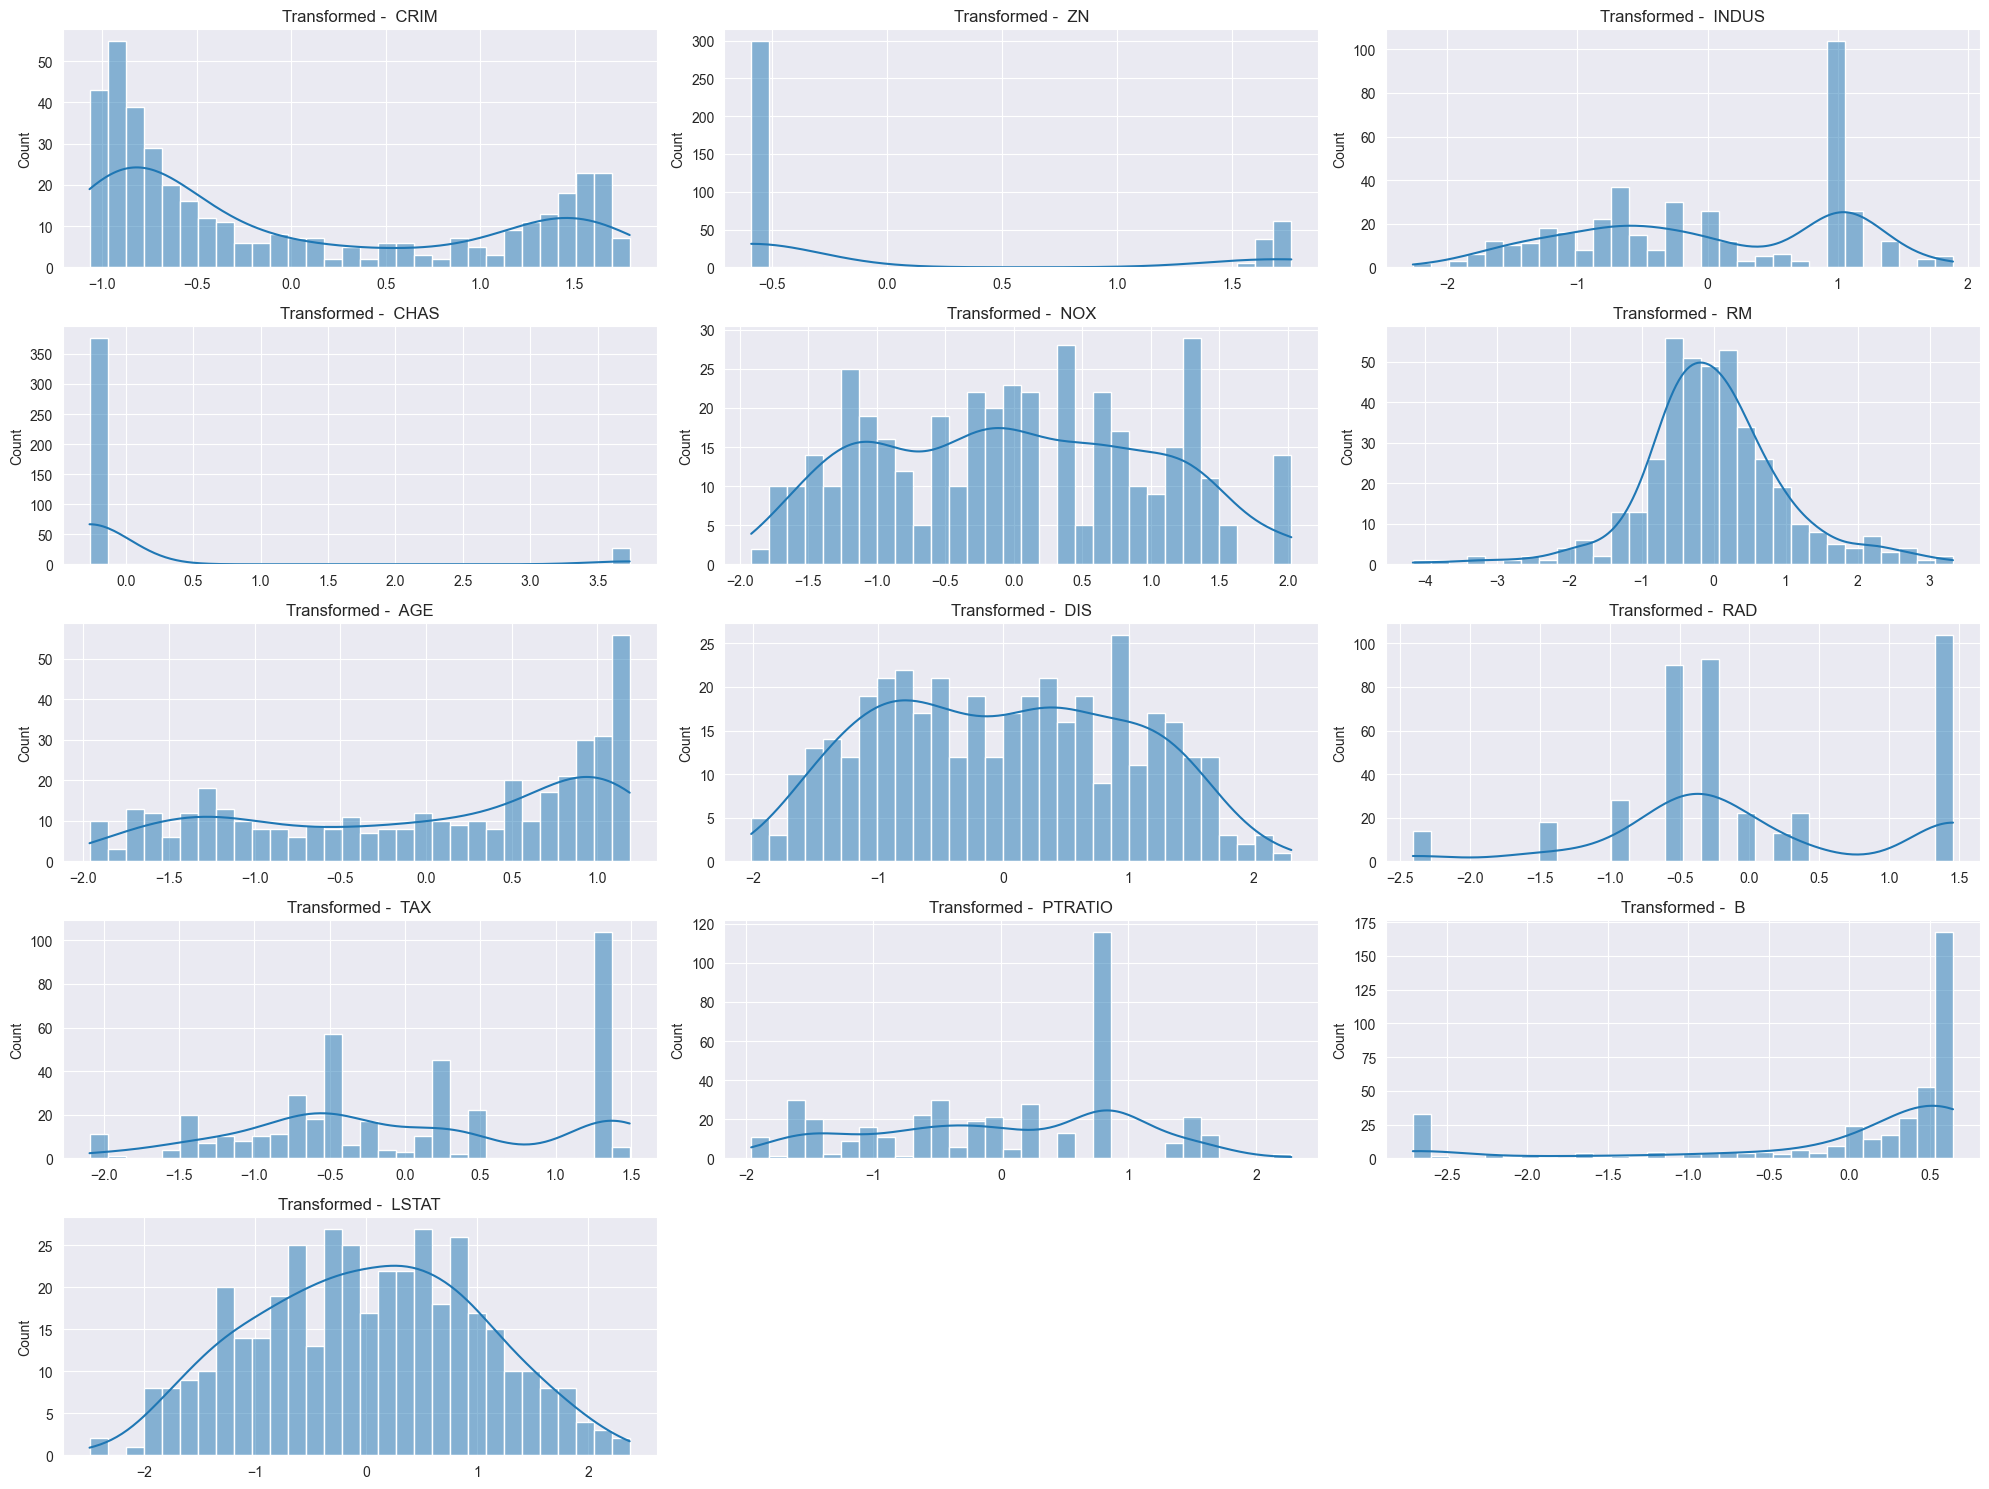

In [52]:
all_hist(X_train_transformed_df, title_pre="Transformed - ")

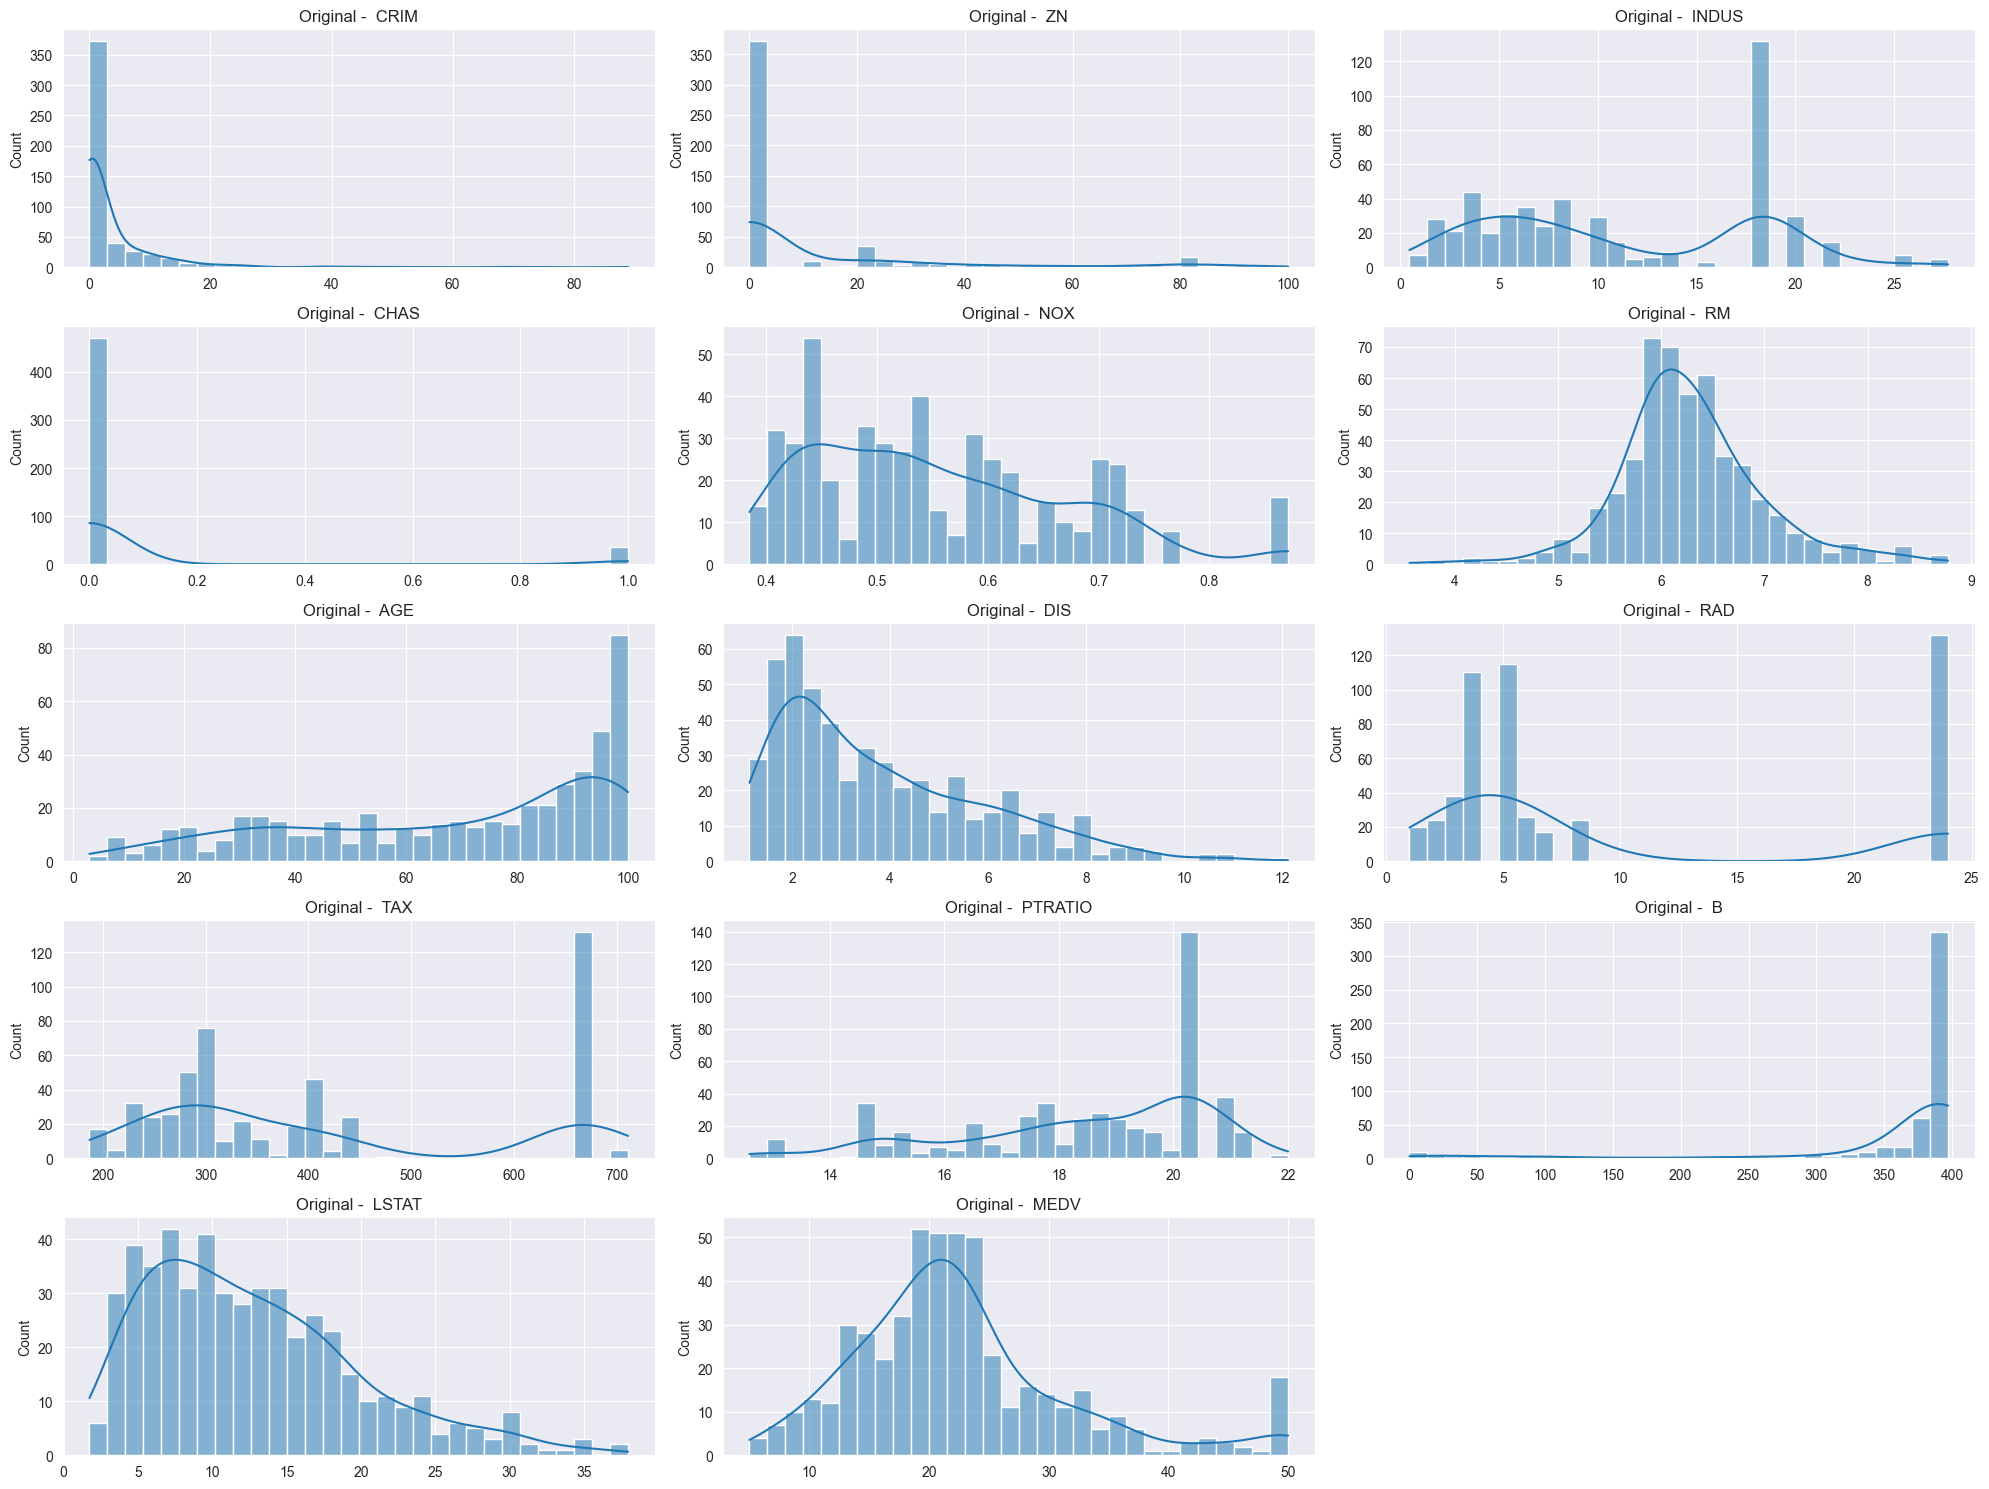

In [53]:
all_hist(data, title_pre="Original - ")

In [54]:
from scipy.stats import boxcox

In [56]:
y_train_transformed, lambda_y = boxcox(y_train)

In [57]:
def inverse_boxcox(y, lambda_):
    if lambda_ ==0:
        return np.exp(y)
    else:
        return np.power(y * lambda_ + 1, 1 / lambda_)

In [58]:
from sklearn.linear_model import LinearRegression

In [59]:
model = LinearRegression()
model.fit(X_train_transformed, y_train_transformed)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [60]:
y_pred_transformed = model.predict(X_test_transformed)

In [61]:
y_pred_original = inverse_boxcox(y_pred_transformed, lambda_y)

In [62]:
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

In [63]:
print("R2 Score: ", r2_score(y_test, y_pred_original))
print("Mean Squared Error: ", mean_squared_error(y_test, y_pred_original))
print("Mean Absolute Error: ", mean_absolute_error(y_test, y_pred_original))

R2 Score:  0.7755639708985015
Mean Squared Error:  17.3559280593146
Mean Absolute Error:  3.0792906212454536


In [65]:
# If you didn't use inverse_boxcox

print("R2 Score: ", r2_score(y_test, y_pred_transformed))
print("Mean Squared Error: ", mean_squared_error(y_test, y_pred_transformed))
print("Mean Absolute Error: ", mean_absolute_error(y_test, y_pred_transformed))

R2 Score:  -3.8466590757184864
Mean Squared Error:  374.79840729205193
Mean Absolute Error:  17.490912372326978


In [72]:
#If you had not done the transformation process

model = LinearRegression()
model.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [73]:
y_pred = model.predict(X_test)

In [74]:
print("R2 Score: ", r2_score(y_test, y_pred))
print("Mean Squared Error: ", mean_squared_error(y_test, y_pred))
print("Mean Absolute Error: ", mean_absolute_error(y_test, y_pred))

R2 Score:  0.6920749038652134
Mean Squared Error:  23.81224546508075
Mean Absolute Error:  3.6860868233802853
